In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
# 1. Load the data
df = pd.read_csv('Iris.csv')
X = df.drop(['Id', 'Species'], axis=1) # Features (4 columns)
y = df['Species']                      # Target labels

In [3]:
# 2. Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# 3. Standardize the features (Crucial for PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# 4. Apply PCA to reduce from 4 dimensions to 2
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [7]:
model = LogisticRegression()


In [9]:
model.fit(X_train_pca, y_train)

LogisticRegression()

In [10]:
predictions = model.predict(X_test_pca)
print(f"Accuracy using 2 PCA components: {accuracy_score(y_test, predictions) * 100:.2f}%")
print(f"Variance explained by these 2 components: {pca.explained_variance_ratio_.sum():.2f}")

Accuracy using 2 PCA components: 90.00%
Variance explained by these 2 components: 0.96


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
pca_df = pd.DataFrame(data=X_train_pca, columns=['PC1', 'PC2'])

In [14]:
pca_df['Species'] = y_train.values

In [17]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

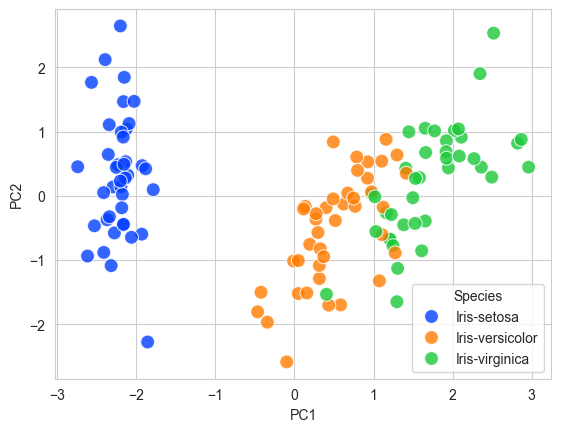

In [18]:
scatter = sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Species', 
    data=pca_df, 
    palette='bright', 
    s=100, 
    alpha=0.8
)